# Notebook 07 — Improved Training

## Objective
Address the two main issues identified in Notebook 06:
- **Overfitting** — training loss (0.04) diverged significantly from validation loss (0.99)
- **upper_fabric imbalance** — cotton represents 81% of samples, causing low precision

## Changes vs Notebook 06
| Component | Notebook 06 | Notebook 07 |
|---|---|---|
| Overfitting control | None | Early stopping + higher dropout |
| Fabric imbalance | Class weights only | Undersampling cotton |
| Epochs | 30 (fixed) | Up to 50 (with early stopping) |

## Inputs
- `train.csv`, `val.csv`, `test.csv` — data splits (Notebook 02)
- DeepFashion-MultiModal images

# 1 — Imports & Environment Check 

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
GPU: Tesla T4
PyTorch version: 2.10.0+cu128


# 2 — Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
NB02_DIR  = Path("/kaggle/input/notebooks/miguelmirandar/02-data-preparation")
IMAGE_DIR = Path("/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/images/images")
CKPT_DIR  = Path("/kaggle/working/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Task definition ──────────────────────────────────────────────────────────
TASKS = {
    "sleeve_length": 4,
    "upper_fabric":  7,
    "upper_color":   7,
}

LABEL_MAPS = {
    "sleeve_length": {0:"sleeveless", 1:"short", 2:"medium", 3:"long"},
    "upper_fabric":  {0:"denim", 1:"cotton", 2:"leather", 3:"furry", 4:"knitted", 5:"chiffon", 6:"other"},
    "upper_color":   {0:"floral", 1:"graphic", 2:"striped", 3:"pure color", 4:"lattice", 5:"other", 6:"color block"},
}

# ── Hyperparameters ──────────────────────────────────────────────────────────
CFG = {
    "img_size":        224,
    "batch_size":      64,
    "num_workers":     2,
    "epochs":          50,
    "lr":              3e-4,
    "weight_decay":    1e-2,
    "dropout":         0.5,   # increased from 0.3
    "patience":        7,     # early stopping patience
    "seed":            42,
    "cotton_max":      1500,  # undersample cotton to this number
}

print("Tasks:", TASKS)
print("Config:", CFG)

Tasks: {'sleeve_length': 4, 'upper_fabric': 7, 'upper_color': 7}
Config: {'img_size': 224, 'batch_size': 64, 'num_workers': 2, 'epochs': 50, 'lr': 0.0003, 'weight_decay': 0.01, 'dropout': 0.5, 'patience': 7, 'seed': 42, 'cotton_max': 1500}


# 3 — Reproducibility & Load Data

In [4]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG["seed"])

# ── Load CSVs ─────────────────────────────────────────────────────────────────
train_df = pd.read_csv(NB02_DIR / "train.csv")
val_df   = pd.read_csv(NB02_DIR / "val.csv")
test_df  = pd.read_csv(NB02_DIR / "test.csv")

# ── Remove not long-sleeve (class 4) ─────────────────────────────────────────
train_df = train_df[train_df["sleeve_length"] != 4].reset_index(drop=True)
val_df   = val_df[val_df["sleeve_length"]     != 4].reset_index(drop=True)
test_df  = test_df[test_df["sleeve_length"]   != 4].reset_index(drop=True)

# ── Undersample cotton (class 1) in training set ──────────────────────────────
cotton_df     = train_df[train_df["upper_fabric"] == 1]
non_cotton_df = train_df[train_df["upper_fabric"] != 1]

cotton_sampled = cotton_df.sample(n=CFG["cotton_max"], random_state=CFG["seed"])
train_df = pd.concat([non_cotton_df, cotton_sampled]).sample(frac=1, random_state=CFG["seed"]).reset_index(drop=True)

print(f"Train samples after undersampling : {len(train_df):,}")
print(f"Val samples                       : {len(val_df):,}")
print(f"Test samples                      : {len(test_df):,}")

print(f"\nFabric distribution (train):")
print(train_df["upper_fabric"].value_counts().sort_index())

Train samples after undersampling : 7,168
Val samples                       : 6,215
Test samples                      : 6,217

Fabric distribution (train):
upper_fabric
0     335
1    1500
2      59
3      97
4    1610
5    3507
6      60
Name: count, dtype: int64


# 4 — Recalculate Class Weights

In [5]:
def compute_class_weights(df, task, num_classes):
    """Compute inverse frequency class weights, normalized to sum to num_classes."""
    counts  = df[task].value_counts().sort_index()
    total   = len(df)
    weights = []
    for i in range(num_classes):
        count = counts.get(i, 1)
        weights.append(total / (num_classes * count))
    return torch.tensor(weights, dtype=torch.float32)

new_weights = {}
for task, num_classes in TASKS.items():
    new_weights[task] = compute_class_weights(train_df, task, num_classes)

print("Recalculated class weights:")
for task, w in new_weights.items():
    print(f"  {task}: {[round(x, 3) for x in w.tolist()]}")

Recalculated class weights:
  sleeve_length: [0.631, 1.886, 4.082, 0.609]
  upper_fabric: [3.057, 0.683, 17.356, 10.557, 0.636, 0.292, 17.067]
  upper_color: [3.066, 0.432, 3.908, 0.275, 15.754, 3.19, 11.253]


# 5 — Dataset & DataLoaders

In [6]:
class GarmentDataset(Dataset):
    """Loads garment images and returns (image, labels_dict) pairs."""

    def __init__(self, df, image_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.image_dir / row["image_name"]
        image    = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = {
            "sleeve_length": torch.tensor(row["sleeve_length"], dtype=torch.long),
            "upper_fabric":  torch.tensor(row["upper_fabric"],  dtype=torch.long),
            "upper_color":   torch.tensor(row["upper_color"],   dtype=torch.long),
        }
        return image, labels


def get_transforms(split, img_size):
    if split == "train":
        return T.Compose([
            T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            T.RandomGrayscale(p=0.05),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])
    else:
        return T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])


train_ds = GarmentDataset(train_df, IMAGE_DIR, get_transforms("train", CFG["img_size"]))
val_ds   = GarmentDataset(val_df,   IMAGE_DIR, get_transforms("val",   CFG["img_size"]))

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train samples : {len(train_ds):,}")
print(f"Val samples   : {len(val_ds):,}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train samples : 7,168
Val samples   : 6,215
Train batches : 112
Val batches   : 98


# 6 — Focal Loss & Model

In [7]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.
    Focuses training on hard, misclassified examples by down-weighting easy ones.
    FL(p) = -alpha * (1 - p)^gamma * log(p)
    """

    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets,
                                              weight=self.weight,
                                              reduction="none")
        pt      = torch.exp(-ce_loss)
        focal   = (1 - pt) ** self.gamma * ce_loss
        return focal.mean()


class GarmentClassifier(nn.Module):
    """EfficientNet-B0 backbone with 3 parallel classification heads."""

    def __init__(self, tasks, dropout):
        super().__init__()

        backbone      = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        in_features   = backbone.classifier[1].in_features

        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Dropout(p=dropout),
                nn.Linear(in_features, num_classes),
            )
            for task, num_classes in tasks.items()
        })

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return {task: head(x) for task, head in self.heads.items()}


# ── Instantiate model ─────────────────────────────────────────────────────────
model = GarmentClassifier(TASKS, CFG["dropout"]).to(device)

# ── Focal loss per task ───────────────────────────────────────────────────────
criteria = {
    task: FocalLoss(weight=new_weights[task].to(device), gamma=2.0)
    for task in TASKS
}

# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-6)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters : {total_params:,}")
print(f"Dropout          : {CFG['dropout']}")
print(f"Loss             : Focal Loss (gamma=2.0) with class weights")
print(f"Optimizer        : AdamW(lr={CFG['lr']}, weight_decay={CFG['weight_decay']})")
print(f"Scheduler        : CosineAnnealingLR(T_max={CFG['epochs']})")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 200MB/s]


Total parameters : 4,030,606
Dropout          : 0.5
Loss             : Focal Loss (gamma=2.0) with class weights
Optimizer        : AdamW(lr=0.0003, weight_decay=0.01)
Scheduler        : CosineAnnealingLR(T_max=50)


# 7 — Training & Validation Functions with Early Stopping

In [8]:
def train_epoch(model, loader, criteria, optimizer, device):
    model.train()
    total_loss = 0.0
    correct    = {task: 0 for task in TASKS}
    total      = 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs   = imgs.to(device)
        labels = {task: labels[task].to(device) for task in TASKS}

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = sum(criteria[task](outputs[task], labels[task]) for task in TASKS)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)
        for task in TASKS:
            preds = outputs[task].argmax(dim=1)
            correct[task] += (preds == labels[task]).sum().item()

    return total_loss / total, {task: correct[task] / total for task in TASKS}


def val_epoch(model, loader, criteria, device):
    model.eval()
    total_loss = 0.0
    correct    = {task: 0 for task in TASKS}
    total      = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Val", leave=False):
            imgs   = imgs.to(device)
            labels = {task: labels[task].to(device) for task in TASKS}

            outputs = model(imgs)
            loss    = sum(criteria[task](outputs[task], labels[task]) for task in TASKS)

            total_loss += loss.item() * imgs.size(0)
            total      += imgs.size(0)
            for task in TASKS:
                preds = outputs[task].argmax(dim=1)
                correct[task] += (preds == labels[task]).sum().item()

    return total_loss / total, {task: correct[task] / total for task in TASKS}


class EarlyStopping:
    """Stops training when validation loss does not improve for 'patience' epochs."""

    def __init__(self, patience, ckpt_path):
        self.patience   = patience
        self.ckpt_path  = ckpt_path
        self.best_loss  = float("inf")
        self.counter    = 0
        self.stopped_at = None

    def step(self, val_loss, epoch, model, optimizer):
        if val_loss < self.best_loss:
            self.best_loss  = val_loss
            self.counter    = 0
            torch.save({
                "epoch":                epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss":             val_loss,
            }, self.ckpt_path)
            return False  # do not stop
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_at = epoch
                return True  # stop
            return False


print("Functions and EarlyStopping defined.")

Functions and EarlyStopping defined.


# 8 — Training Loop with Early Stopping

In [9]:
history      = []
early_stop   = EarlyStopping(patience=CFG["patience"], ckpt_path=CKPT_DIR / "best_model_v3.pt")

for epoch in range(1, CFG["epochs"] + 1):

    # ── Train ────────────────────────────────────────────────────────────────
    train_loss, train_acc = train_epoch(model, train_loader, criteria, optimizer, device)

    # ── Validate ─────────────────────────────────────────────────────────────
    val_loss, val_acc = val_epoch(model, val_loader, criteria, device)

    # ── Scheduler step ───────────────────────────────────────────────────────
    scheduler.step()

    # ── Log ──────────────────────────────────────────────────────────────────
    history.append({
        "epoch":            epoch,
        "train_loss":       train_loss,
        "val_loss":         val_loss,
        "train_acc_sleeve": train_acc["sleeve_length"],
        "train_acc_fabric": train_acc["upper_fabric"],
        "train_acc_color":  train_acc["upper_color"],
        "val_acc_sleeve":   val_acc["sleeve_length"],
        "val_acc_fabric":   val_acc["upper_fabric"],
        "val_acc_color":    val_acc["upper_color"],
    })

    print(
        f"Epoch {epoch:02d}/{CFG['epochs']} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc — sleeve: {val_acc['sleeve_length']:.3f} "
        f"fabric: {val_acc['upper_fabric']:.3f} "
        f"color: {val_acc['upper_color']:.3f}"
    )

    # ── Early stopping ────────────────────────────────────────────────────────
    stop = early_stop.step(val_loss, epoch, model, optimizer)
    if stop:
        print(f"\n  Early stopping triggered at epoch {epoch} (patience={CFG['patience']})")
        break
    elif val_loss == early_stop.best_loss:
        print(f"  Best model saved (val_loss={val_loss:.4f})")

print("\nTraining complete.")

Train:   0%|          | 0/112 [00:00<?, ?it/s]

Val:   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79db39b3dee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79db39b3dee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 01/50 | Train loss: 2.8799 | Val loss: 1.6896 | Val acc — sleeve: 0.622 fabric: 0.353 color: 0.241
  Best model saved (val_loss=1.6896)


Train:   0%|          | 0/112 [00:00<?, ?it/s]

...

Val:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 10/50 | Train loss: 0.2707 | Val loss: 1.6499 | Val acc — sleeve: 0.906 fabric: 0.602 color: 0.551


Train:   0%|          | 0/112 [00:00<?, ?it/s]

Val:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 11/50 | Train loss: 0.3001 | Val loss: 1.2395 | Val acc — sleeve: 0.899 fabric: 0.719 color: 0.602

  Early stopping triggered at epoch 11 (patience=7)

Training complete.


# 9 — Training Curves

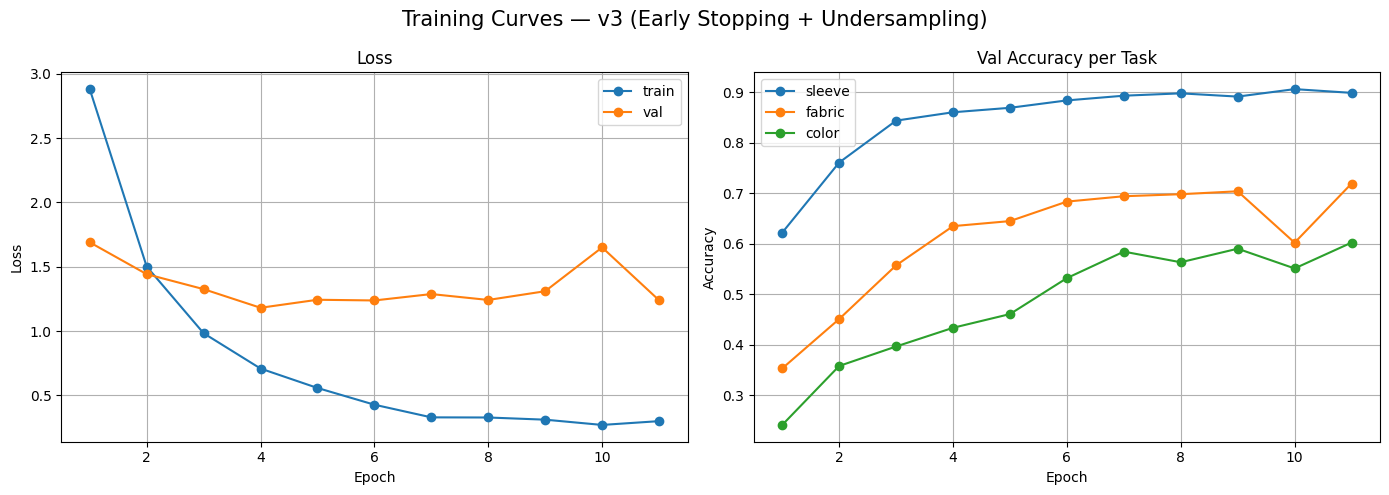

Saved: training_curves_v3.png, training_history_v3.csv


In [10]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss ─────────────────────────────────────────────────────────────────────
axes[0].plot(df_hist["epoch"], df_hist["train_loss"], label="train", marker="o")
axes[0].plot(df_hist["epoch"], df_hist["val_loss"],   label="val",   marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ── Accuracy per task ─────────────────────────────────────────────────────────
axes[1].plot(df_hist["epoch"], df_hist["val_acc_sleeve"], label="sleeve", marker="o")
axes[1].plot(df_hist["epoch"], df_hist["val_acc_fabric"], label="fabric", marker="o")
axes[1].plot(df_hist["epoch"], df_hist["val_acc_color"],  label="color",  marker="o")
axes[1].set_title("Val Accuracy per Task")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training Curves — v3 (Early Stopping + Undersampling)", fontsize=15)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_v3.png", dpi=150)
plt.show()

df_hist.to_csv("/kaggle/working/training_history_v3.csv", index=False)
print("Saved: training_curves_v3.png, training_history_v3.csv")

# 10 — Evaluation on Test Set

In [11]:
from sklearn.metrics import classification_report

# ── Load best model ───────────────────────────────────────────────────────────
checkpoint = torch.load(CKPT_DIR / "best_model_v3.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Best model from epoch : {checkpoint['epoch']}")
print(f"Val loss              : {checkpoint['val_loss']:.4f}")

# ── Test DataLoader ───────────────────────────────────────────────────────────
test_ds     = GarmentDataset(test_df, IMAGE_DIR, get_transforms("val", CFG["img_size"]))
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False,
                         num_workers=CFG["num_workers"], pin_memory=True)

# ── Inference ─────────────────────────────────────────────────────────────────
all_preds  = {task: [] for task in TASKS}
all_labels = {task: [] for task in TASKS}

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs    = imgs.to(device)
        outputs = model(imgs)
        for task in TASKS:
            all_preds[task].extend(outputs[task].argmax(dim=1).cpu().numpy())
            all_labels[task].extend(labels[task].numpy())

all_preds  = {task: np.array(all_preds[task])  for task in TASKS}
all_labels = {task: np.array(all_labels[task]) for task in TASKS}

# ── Results ───────────────────────────────────────────────────────────────────
print("\nTest Accuracy:")
for task in TASKS:
    acc = (all_preds[task] == all_labels[task]).mean()
    print(f"  {task}: {acc:.4f}")

Best model from epoch : 4
Val loss              : 1.1809


Evaluating:   0%|          | 0/98 [00:00<?, ?it/s]


Test Accuracy:
  sleeve_length: 0.8583
  upper_fabric: 0.6320
  upper_color: 0.4304


# 11 — Classification Report

In [12]:
for task in TASKS:
    label_names = [LABEL_MAPS[task][i] for i in range(TASKS[task])]

    print(f"\n{'='*60}")
    print(f" Task: {task}")
    print(f"{'='*60}")
    print(classification_report(
        all_labels[task],
        all_preds[task],
        target_names=label_names,
        zero_division=0
    ))


 Task: sleeve_length
              precision    recall  f1-score   support

  sleeveless       0.99      0.89      0.93      2561
       short       0.78      0.95      0.86      1339
      medium       0.35      0.72      0.47       332
        long       0.97      0.78      0.87      1985

    accuracy                           0.86      6217
   macro avg       0.77      0.83      0.78      6217
weighted avg       0.90      0.86      0.87      6217


 Task: upper_fabric
              precision    recall  f1-score   support

       denim       0.14      0.90      0.24        70
      cotton       0.90      0.66      0.76      5041
     leather       0.05      0.81      0.09        16
       furry       0.16      0.94      0.28        18
     knitted       0.29      0.75      0.42       330
     chiffon       0.49      0.36      0.41       731
       other       0.03      0.73      0.05        11

    accuracy                           0.63      6217
   macro avg       0.29      0.74 

## Results

| Model | sleeve_length Acc | upper_fabric Acc | upper_color Acc |
|---|---|---|---|
| v1 — Weighted CrossEntropy | 0.017 | 0.084 | 0.844 |
| v2 — Focal Loss | 0.943 | 0.503 | 0.758 |
| v3 — Focal Loss + Undersampling | 0.858 | 0.632 | 0.430 |

## Conclusions

The three training iterations reveal a clear progression and trade-off between tasks:

- **v1** failed on sleeve and fabric due to extreme class imbalance and inadequate loss function.
- **v2** resolved sleeve_length almost entirely (2% → 94%) and improved fabric significantly. The main remaining issue was overfitting.
- **v3** introduced early stopping and cotton undersampling. Fabric improved further (50% → 63%) but upper_color degraded significantly (76% → 43%) — the aggressive undersampling removed too many training samples for color patterns to be learned effectively.

**Best overall model: v2** — it achieves the best balance across all three tasks.

The core limitation of this project is the dataset imbalance in upper_fabric, where cotton represents 81% of samples. Undersampling helps fabric but hurts color. A better solution would require either a more balanced dataset or training separate models per task.